In [3]:
import pickle

with open("NIOSH_Combined_Dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

ts_data = loaded_data["ts_data"]
anthro_clean = loaded_data["anthro_clean"]
experiment_settings = loaded_data["experiment_settings"]

In [4]:
for name, data in [("ts_data", ts_data), ("anthro_clean", anthro_clean), ("experiment_settings", experiment_settings)]:
    print(f"--- {name} ---")
    print(f"Type: {type(data)}")
    if hasattr(data, 'shape'):
        print(f"Shape: {data.shape}")
    elif hasattr(data, 'keys'):
        print(f"Keys: {list(data.keys())}")
    elif isinstance(data, list):
        print(f"Length: {len(data)}")
    print()


--- ts_data ---
Type: <class 'dict'>
Keys: [('Sub01', 'Session1'), ('Sub01', 'Session2'), ('Sub01', 'Session3'), ('Sub01', 'Session4'), ('Sub02', 'Session1'), ('Sub02', 'Session2'), ('Sub02', 'Session3'), ('Sub02', 'Session4'), ('Sub03', 'Session1'), ('Sub03', 'Session2'), ('Sub03', 'Session3'), ('Sub03', 'Session4'), ('Sub04', 'Session1'), ('Sub04', 'Session2'), ('Sub04', 'Session3'), ('Sub04', 'Session4'), ('Sub05', 'Session1'), ('Sub05', 'Session2'), ('Sub05', 'Session3'), ('Sub05', 'Session4'), ('Sub06', 'Session1'), ('Sub06', 'Session2'), ('Sub06', 'Session3'), ('Sub06', 'Session4'), ('Sub07', 'Session1'), ('Sub07', 'Session2'), ('Sub07', 'Session3'), ('Sub07', 'Session4'), ('Sub08', 'Session1'), ('Sub08', 'Session2'), ('Sub08', 'Session3'), ('Sub08', 'Session4'), ('Sub09', 'Session1'), ('Sub09', 'Session2'), ('Sub09', 'Session3'), ('Sub09', 'Session4'), ('Sub10', 'Session1'), ('Sub10', 'Session2'), ('Sub10', 'Session3'), ('Sub10', 'Session4'), ('Sub11', 'Session1'), ('Sub12', 'Se

In [5]:
anthro_clean

,Subject,Gender,Age,Height (cm),Weight (kg),Waist circumference (cm),Hip circumference (cm)
0,Sub01,M,20,170.180,68.038855,84.328,93.98
1,Sub02,M,20,179.000,87.000000,90.000,107.00
2,Sub03,F,28,163.000,72.000000,69.000,112.00
3,Sub04,M,27,179.000,70.000000,83.500,93.00
4,Sub05,M,24,180.340,83.007404,74.930,81.28
5,Sub06,F,30,164.000,52.000000,71.000,98.00
6,Sub07,F,27,167.640,64.410117,99.060,104.14
7,Sub08,F,29,164.000,50.000000,66.040,87.63
8,Sub09,M,32,183.000,83.000000,97.000,103.00
9,Sub10,F,21,139.700,56.699046,81.280,96.52


In [6]:
# Grab the very first session data
sample_session = ts_data[('Sub01', 'Session1')]

print(f"Data type inside session: {type(sample_session)}")
if hasattr(sample_session, 'head'):
    print(sample_session.head())  # If it's a Pandas DataFrame
else:
    print(sample_session[:5])     # If it's a NumPy array or list


Data type inside session: <class 'pandas.DataFrame'>
  Subject   Session     Timestamp  trunk_Accelerometer.X  \
0   Sub01  Session1  1.631984e+09               0.935214   
1   Sub01  Session1  1.631984e+09               0.940186   
2   Sub01  Session1  1.631984e+09               0.952560   
3   Sub01  Session1  1.631984e+09               0.969516   
4   Sub01  Session1  1.631984e+09               0.987153   

   trunk_Accelerometer.Y  trunk_Accelerometer.Z  trunk_Gyroscope.X  \
0               0.156098              -0.150236         -27.465822   
1               0.170378              -0.153184         -29.846193   
2               0.182498              -0.156682         -32.592775   
3               0.189810              -0.160779         -35.888674   
4               0.190586              -0.165351         -39.245608   

   trunk_Gyroscope.Y  trunk_Gyroscope.Z  trunk_Magnetometer.X  ...  \
0         -11.840821           6.469727             14.648437  ...   
1         -11.535645     

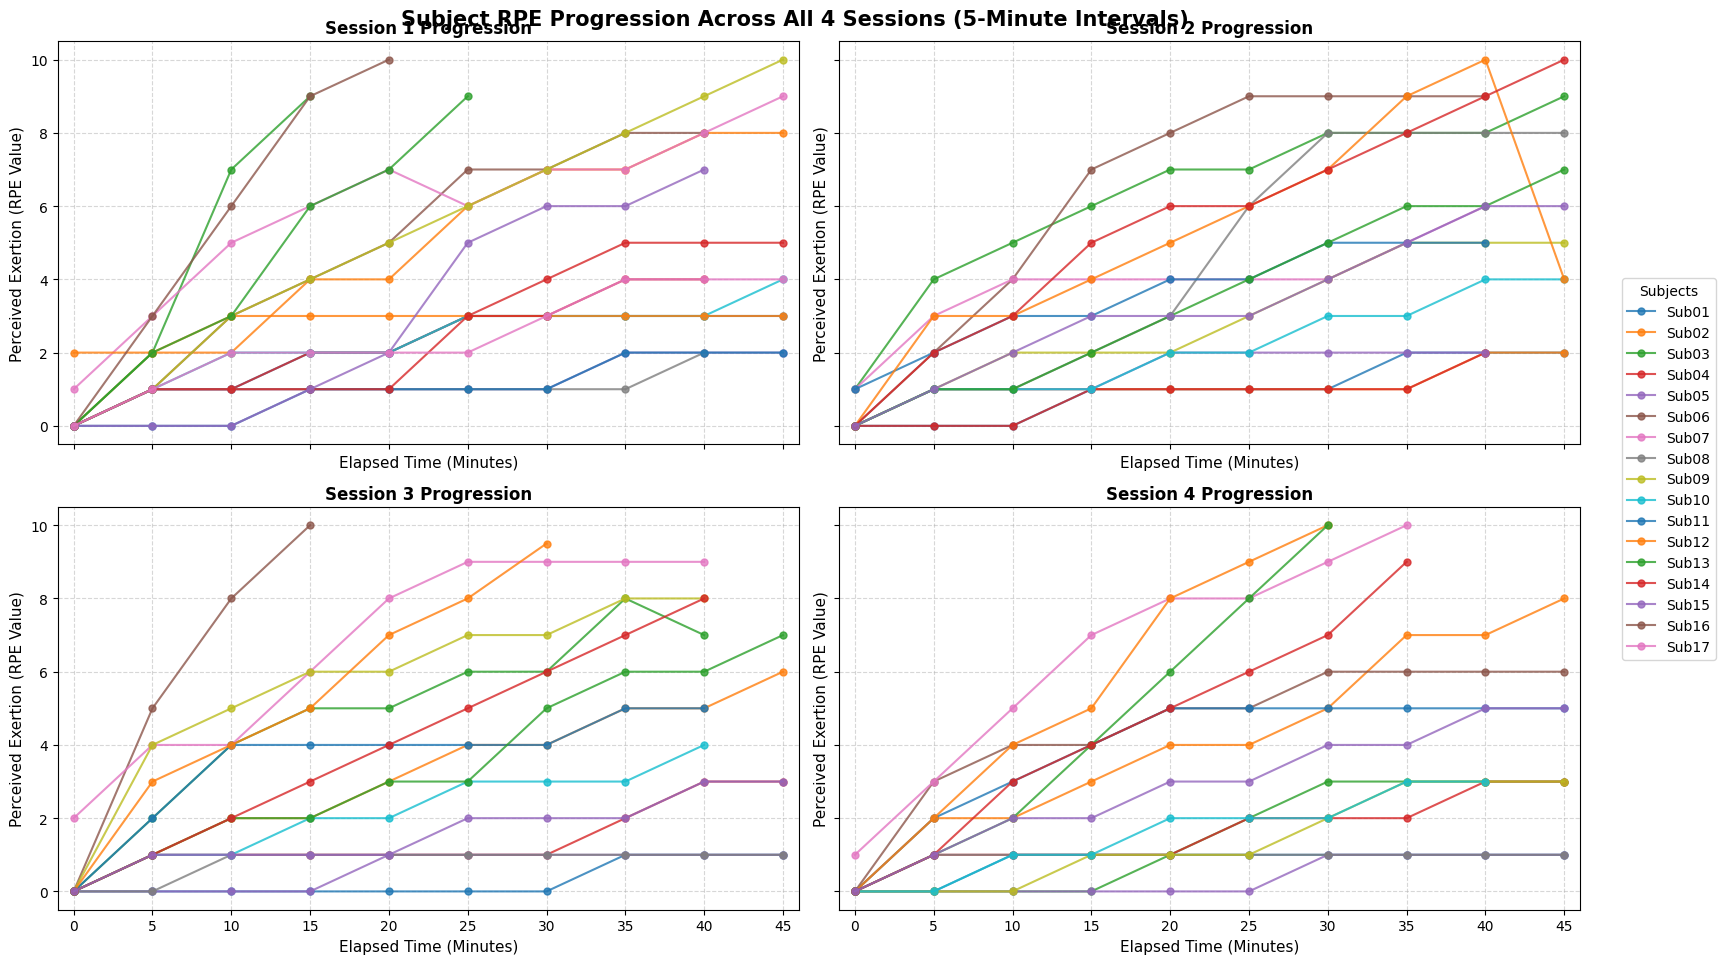

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to a 1D array for easy indexing (0 to 3)

sessions = ['Session1', 'Session2', 'Session3', 'Session4']
FORTY_FIVE_MINUTES_IN_SEC = 45 * 60  

# Get a sorted list of all unique subjects across the dataset
unique_subjects = sorted(list(set(key[0] for key in ts_data.keys())))

# Loop through each session to create its respective subplot
for idx, session_name in enumerate(sessions):
    ax = axes[idx]
    
    for sub in unique_subjects:
        key = (sub, session_name)
        if key not in ts_data:
            continue
            
        df = ts_data[key]
        
        # Clean up session target matching
        df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
        
        if df_session.empty:
            continue
            
        # Get baseline start time for this specific session
        start_unix_time = df_session['Timestamp'].min()
        
        # Calculate exact elapsed minutes
        df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_unix_time) / 60
        
        # Filter for the first 45 minutes
        df_45min = df_session[(df_session['Elapsed_Minutes'] >= 0) & (df_session['Elapsed_Minutes'] <= 45)].copy()
        
        # Drop rows without an RPE score
        df_rpe = df_45min.dropna(subset=['RPE_Val']).copy()
        
        if not df_rpe.empty:
            # Snap elapsed minutes to the nearest 5-minute interval (0, 5, 10, ..., 45)
            df_rpe['Interval_Minutes'] = (df_rpe['Elapsed_Minutes'] / 5).round() * 5
            
            # Group by interval to get a single RPE value per 5-minute block
            df_grouped = df_rpe.groupby('Interval_Minutes')['RPE_Val'].mean().reset_index()
            df_grouped = df_grouped[df_grouped['Interval_Minutes'] <= 45]
            
            # Plot line for the subject on the current axis
            ax.plot(df_grouped['Interval_Minutes'], df_grouped['RPE_Val'], '-o', label=sub, alpha=0.8, markersize=5, linewidth=1.5)
            
    # Subplot styling
    ax.set_title(f"{session_name.replace('Session', 'Session ')} Progression", fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(0, 46, 5))
    ax.set_xlim(-1, 46)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add shared X and Y axis labels to the outer bounds
for i in range(4):
    axes[i].set_ylabel("Perceived Exertion (RPE Value)", fontsize=11)
for i in range(4):
    axes[i].set_xlabel("Elapsed Time (Minutes)", fontsize=11)

# Place a single, unified legend to the right of the subplots
handles, labels = axes[0].get_legend_handles_labels()
# Sort the legend handles/labels by subject name for clean display
if handles:
    sorted_legend = sorted(zip(labels, handles), key=lambda t: t[0])
    labels, handles = zip(*sorted_legend)
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), title="Subjects")

plt.suptitle("Subject RPE Progression Across All 4 Sessions (5-Minute Intervals)", fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()


In [8]:
import pprint

# Pretty print the settings dictionary for Subject 1
pprint.pprint(experiment_settings['Sub01'])


          Weight  Pace
Session1     2.5    15
Session2     2.5    10
Session3     2.5     5
Session4     1.5    15


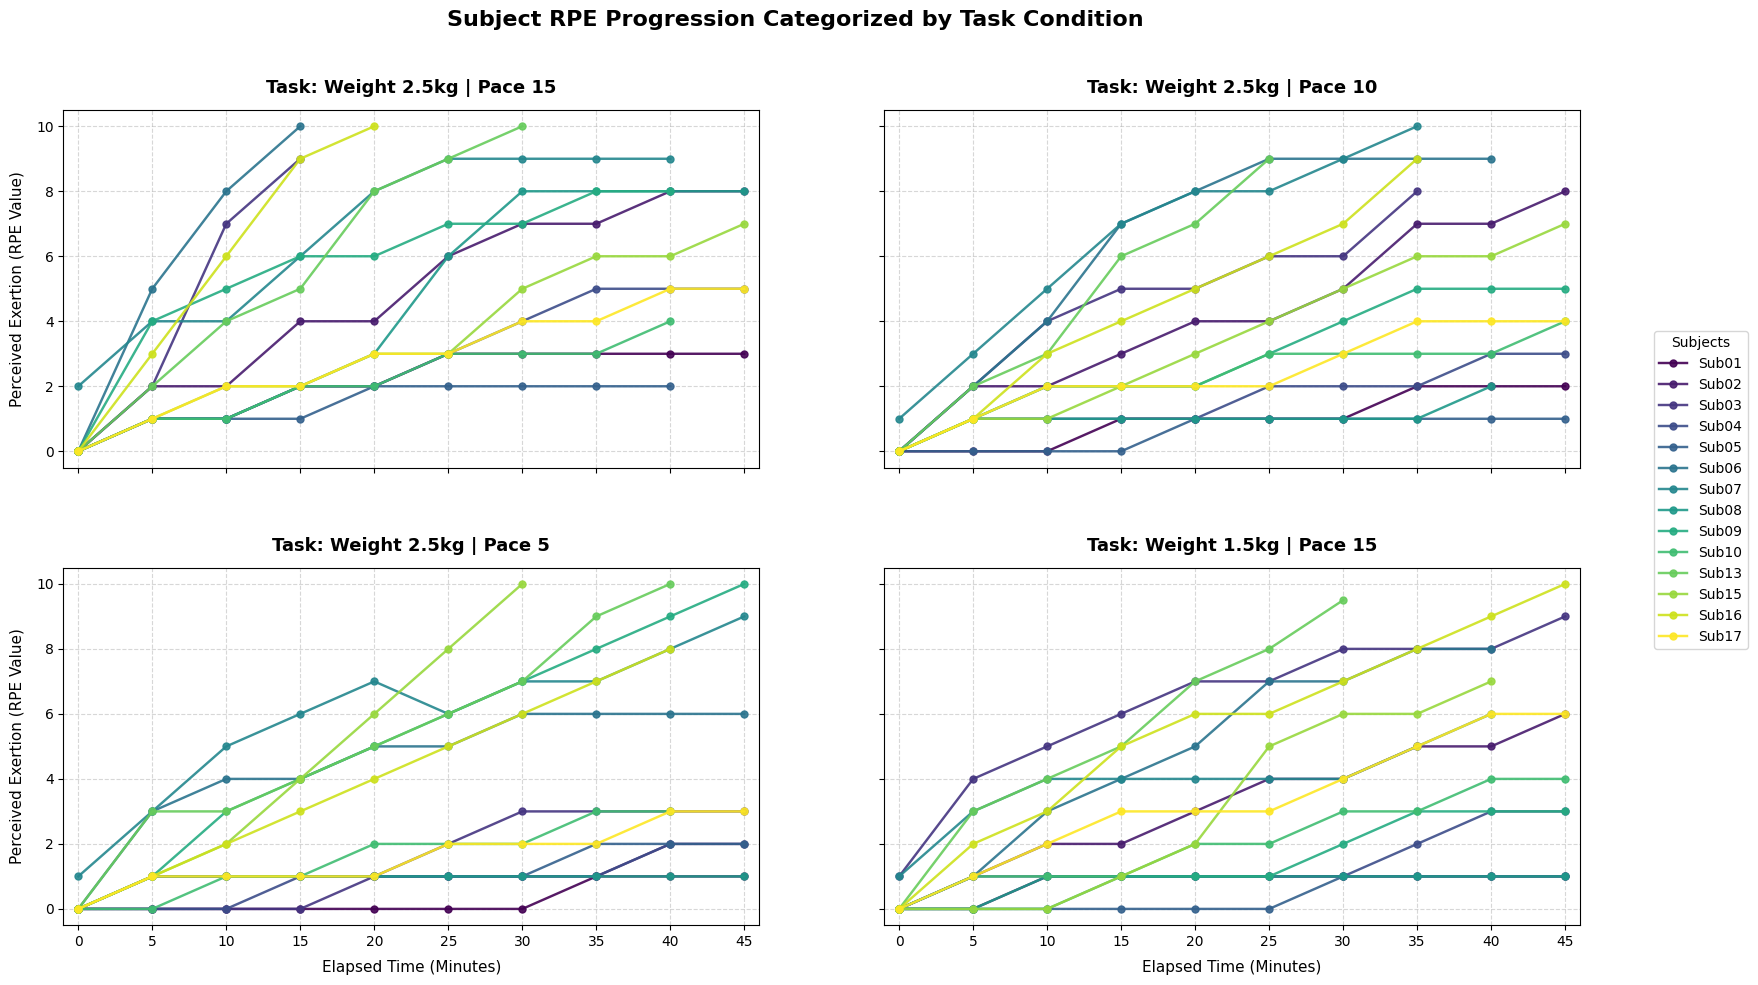

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define our 4 distinct experimental conditions (Tasks)
tasks = [
    {"Weight": 2.5, "Pace": 15},
    {"Weight": 2.5, "Pace": 10},
    {"Weight": 2.5, "Pace": 5},
    {"Weight": 1.5, "Pace": 15}
]

# Set up a 2x2 grid of subplots mapped to conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

sessions_list = ['Session1', 'Session2', 'Session3', 'Session4']
exclude_subjects = {'Sub11', 'Sub12', 'Sub14'}

# Extract and filter unique subject IDs
all_keys = list(ts_data.keys())
unique_subjects = sorted(list(set(k[0] if isinstance(k, tuple) else k for k in all_keys)))
filtered_subjects = [sub for sub in unique_subjects if sub not in exclude_subjects]

# Create an accessible, color-blind friendly viridis color mapping for each remaining subject
colors = plt.cm.viridis(np.linspace(0, 1, len(filtered_subjects)))
subject_colors = dict(zip(filtered_subjects, colors))

# Helper function to find which session matches a specific task for a given subject
def get_matching_session(subject, target_weight, target_pace):
    if subject not in experiment_settings:
        return None
    settings = experiment_settings[subject]
    
    # CASE A: If settings is a Pandas DataFrame or Series
    if hasattr(settings, 'loc') or isinstance(settings, pd.DataFrame):
        df_set = pd.DataFrame(settings).copy()
        df_set.columns = [str(c).capitalize() for c in df_set.columns]
        match = df_set[(df_set['Weight'] == target_weight) & (df_set['Pace'] == target_pace)]
        
        if not match.empty:
            if 'Session' in match.columns:
                return str(match['Session'].values[0]).strip()
            else:
                return str(match.index[0]).strip()
                
    # CASE B: If settings is a standard nested Python dictionary
    if isinstance(settings, dict):
        for sess in sessions_list:
            if sess in settings:
                sub_dict = settings[sess]
                if isinstance(sub_dict, dict):
                    w = sub_dict.get('Weight', sub_dict.get('weight'))
                    p = sub_dict.get('Pace', sub_dict.get('pace'))
                    if w == target_weight and p == target_pace:
                        return sess.strip()
                        
    return None

# Loop through each task and draw its subplot
for idx, task in enumerate(tasks):
    ax = axes[idx]
    w_target = task["Weight"]
    p_target = task["Pace"]
    
    for sub in filtered_subjects:
        session_name = get_matching_session(sub, w_target, p_target)
        
        if not session_name:
            continue  
            
        key = (sub, session_name)
        if key not in ts_data:
            continue
            
        df = ts_data[key]
        df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
        
        if df_session.empty:
            continue
            
        # Standardize the timeline starting point
        start_unix_time = df_session['Timestamp'].min()
        df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_unix_time) / 60
        
        # Isolate the first 45 minutes and drop NaNs
        df_45min = df_session[(df_session['Elapsed_Minutes'] >= 0) & (df_session['Elapsed_Minutes'] <= 45)].copy()
        df_rpe = df_45min.dropna(subset=['RPE_Val']).copy()
        
        if not df_rpe.empty:
            # Snap to 5-minute reporting intervals
            df_rpe['Interval_Minutes'] = (df_rpe['Elapsed_Minutes'] / 5).round() * 5
            df_grouped = df_rpe.groupby('Interval_Minutes')['RPE_Val'].mean().reset_index()
            df_grouped = df_grouped[df_grouped['Interval_Minutes'] <= 45]
            
            # CRITICAL CLEANUP: Remove the last rest-period RPE tracking points
            if (sub == 'Sub13' and session_name == 'Session2') or (sub == 'Sub03' and session_name == 'Session3'):
                if not df_grouped.empty:
                    df_grouped = df_grouped.iloc[:-1] # Drops the very last recorded timestamp row
            
            # Plot using the unique color assignment
            ax.plot(df_grouped['Interval_Minutes'], df_grouped['RPE_Val'], '-o', 
                    label=sub, color=subject_colors[sub], alpha=0.9, markersize=5, linewidth=1.75)
            
    # Style individual subplots
    ax.set_title(f"Task: Weight {w_target}kg | Pace {p_target}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(np.arange(0, 46, 5))
    ax.set_xlim(-1, 46)
    ax.grid(True, linestyle="--", alpha=0.5)

# Standardized Axis Labels applied across rows/columns
for i, ax in enumerate(axes):
    if i in [0, 2]: # Left columns
        ax.set_ylabel("Perceived Exertion (RPE Value)", fontsize=11, labelpad=8)
    if i in [2, 3]: # Bottom rows
        ax.set_xlabel("Elapsed Time (Minutes)", fontsize=11, labelpad=8)

# Generate a unified, clean legend from the axes map matrix
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    sorted_labels = sorted(by_label.keys())
    sorted_handles = [by_label[l] for l in sorted_labels]
    fig.legend(sorted_handles, sorted_labels, loc='center right', bbox_to_anchor=(1.10, 0.5), title="Subjects")

# Master Super Title Layout
plt.suptitle("Subject RPE Progression Categorized by Task Condition", fontsize=16, fontweight='bold', y=0.98)

# Tight layout call followed by specific manual layout expansions for white space padding
plt.tight_layout()
plt.subplots_adjust(wspace=0.18, hspace=0.28, top=0.88) 
plt.show()


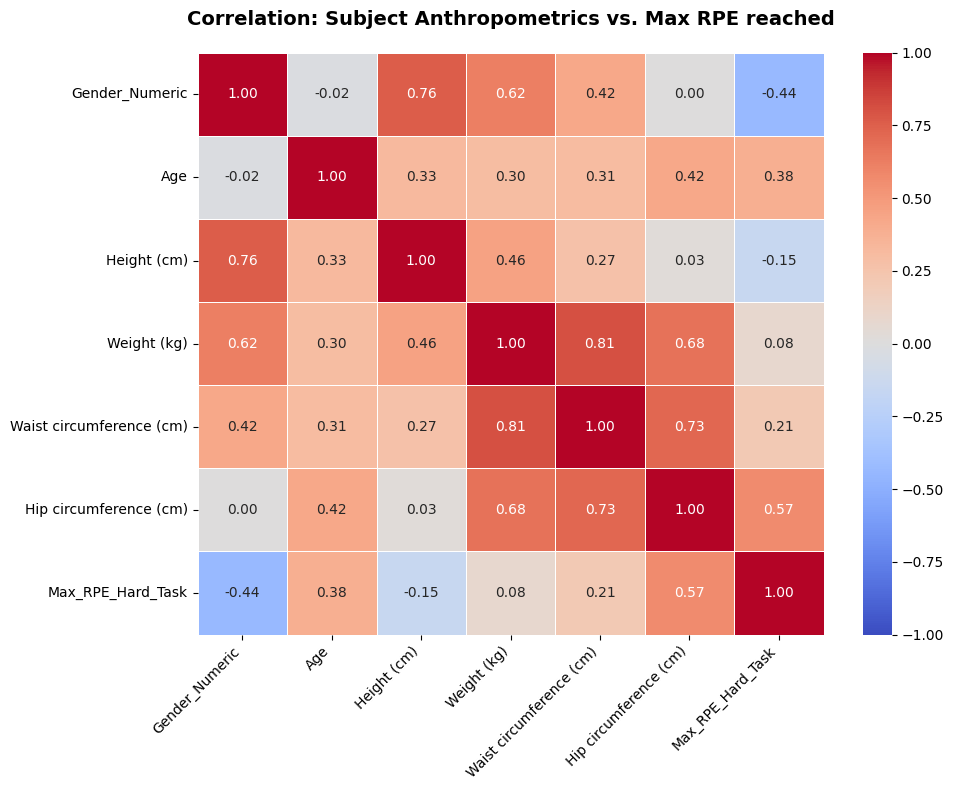

--- Correlation with Max RPE reached ---
Max_RPE_Hard_Task           1.000000
Hip circumference (cm)      0.569436
Age                         0.383431
Waist circumference (cm)    0.212786
Weight (kg)                 0.084480
Height (cm)                -0.153542
Gender_Numeric             -0.436436
Name: Max_RPE_Hard_Task, dtype: float64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- STEP 1: Compute a metric for RPE per subject ---
# We will find each subject's maximum RPE reached during the hardest task (Weight 2.5kg | Pace 15)
target_weight = 2.5
target_pace = 15
sessions_list = ['Session1', 'Session2', 'Session3', 'Session4']
exclude_subjects = {'Sub11', 'Sub12', 'Sub14'}

subject_rpe_metrics = []

# Re-use your helper function to map the task to the session name
def get_matching_session_local(subject, target_weight, target_pace):
    if subject not in experiment_settings: return None
    settings = experiment_settings[subject]
    if hasattr(settings, 'loc') or isinstance(settings, pd.DataFrame):
        df_set = pd.DataFrame(settings).copy()
        df_set.columns = [str(c).capitalize() for c in df_set.columns]
        match = df_set[(df_set['Weight'] == target_weight) & (df_set['Pace'] == target_pace)]
        if not match.empty:
            return str(match['Session'].iloc[0]).strip() if 'Session' in match.columns else str(match.index[0]).strip()
    return None

# Extract the Max RPE for each valid subject
for sub in anthro_clean['Subject'].unique():
    if sub in exclude_subjects:
        continue
    session_name = get_matching_session_local(sub, target_weight, target_pace)
    if session_name and (sub, session_name) in ts_data:
        df = ts_data[(sub, session_name)]
        # Filter for the 45-minute window and drop NaNs
        start_time = df['Timestamp'].min()
        df_45min = df[(df['Timestamp'] - start_time) / 60 <= 45]
        valid_rpe = df_45min['RPE_Val'].dropna()
        
        if not valid_rpe.empty:
            # Save the max RPE reached by this subject during this intense task
            subject_rpe_metrics.append({'Subject': sub, 'Max_RPE_Hard_Task': valid_rpe.max()})

rpe_df = pd.DataFrame(subject_rpe_metrics)

# --- STEP 2: Merge RPE with Anthropological Data ---
# Ensure anthro_clean columns match your printout
df_analysis = pd.merge(anthro_clean, rpe_df, on='Subject')

# Convert Gender to numeric (0 for Female, 1 for Male) so it can be correlated
df_analysis['Gender_Numeric'] = df_analysis['Gender'].map({'M': 1, 'F': 0})

# Select only numeric columns for the correlation check
numeric_cols = [
    'Gender_Numeric', 'Age', 'Height (cm)', 'Weight (kg)', 
    'Waist circumference (cm)', 'Hip circumference (cm)', 'Max_RPE_Hard_Task'
]
df_numeric = df_analysis[numeric_cols]

# --- STEP 3: Calculate and Plot Correlation Matrix ---
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
# Visualizing with an accessible coolwarm diverging colormap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title("Correlation: Subject Anthropometrics vs. Max RPE reached", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- STEP 4: Print the strongest relationships ---
print("--- Correlation with Max RPE reached ---")
print(corr_matrix['Max_RPE_Hard_Task'].sort_values(ascending=False))


Larger hip size reported higher RPE
Gender: Female (0) reported higher max RPE val then men.
Age: older sub reported higher rpe (expected)
Waist, height: weak corr
weight- no corr (surprisingly)

High corr between height/gender and weight/waist/hip due to body types. These traits would need to be isolated to figure if they would be a good feature for the model. (Maybe use linreg)

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Define the sensor components we want to profile
body_segments = ['trunk', 'upper_arm', 'wrist']
sensor_types = ['Accelerometer', 'Gyroscope', 'Magnetometer']
axes = ['X', 'Y', 'Z']

# Build a list of baseline numeric columns we are tracking
sensor_cols = []
for segment in body_segments:
    for s_type in sensor_types:
        for ax in axes:
            col_name = f"{segment}_{s_type}.{ax}"
            sensor_cols.append(col_name)

# 2. Extract windowed summaries matched with valid RPE intervals
windowed_features = []
exclude_subjects = {'Sub11', 'Sub12', 'Sub14'}

for key, df in ts_data.items():
    sub, session_name = key
    if sub in exclude_subjects:
        continue
        
    # Standardize and isolate the specific session track
    df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
    if df_session.empty:
        continue
        
    # Verify all needed sensor headers exist in this chunk
    available_sensors = [c for c in sensor_cols if c in df_session.columns]
    if not available_sensors:
        continue
        
    # Find rows where an actual RPE survey was filled out
    rpe_indices = df_session['RPE_Val'].dropna().index
    
    for idx in rpe_indices:
        rpe_target = df_session.loc[idx, 'RPE_Val']
        current_time = df_session.loc[idx, 'Timestamp']
        
        # Isolate a 10-second activity window immediately preceding the RPE logging event
        # (This avoids capturing baseline artifacts while catching active load signals)
        window_df = df_session[(df_session['Timestamp'] <= current_time) & 
                               (df_session['Timestamp'] >= current_time - 10)]
        
        if window_df.empty or len(window_df) < 50:
            continue
            
        # Build our feature dictionary for this milestone point
        row_features = {'Subject': sub, 'RPE_Target': rpe_target}
        
        for col in available_sensors:
            signal_data = window_df[col].values
            
            # Extract primary statistical fatigue indicators
            row_features[f"{col}_Mean"] = np.mean(signal_data)
            row_features[f"{col}_Std"] = np.std(signal_data)
            row_features[f"{col}_RMS"] = np.sqrt(np.mean(signal_data**2))
            
        windowed_features.append(row_features)

# 3. Compile the feature matrix and compute the correlation rank
features_df = pd.DataFrame(windowed_features)
numeric_features = features_df.drop(columns=['Subject'])

# Calculate Pearson product-moment correlations relative to our RPE column
rpe_correlations = numeric_features.corr()['RPE_Target'].drop('RPE_Target')

# Split into positive and negative drivers for model selection mapping
top_positive = rpe_correlations.sort_values(ascending=False).head(10)
top_negative = rpe_correlations.sort_values(ascending=True).head(10)

print("="*60)
print("TOP 10 POSITIVE SENSOR CORRELATIONS WITH RPE (FATIGUE INCREASES SIGNAL)")
print("="*60)
print(top_positive.to_string())
print("\n")
print("="*60)
print("TOP 10 NEGATIVE SENSOR CORRELATIONS WITH RPE (SIGNAL DAMPENS WITH FATIGUE)")
print("="*60)
print(top_negative.to_string())
print("="*60)


🏆 TOP 10 POSITIVE SENSOR CORRELATIONS WITH RPE (FATIGUE INCREASES SIGNAL)
wrist_Magnetometer.Z_Std         0.385020
upper_arm_Accelerometer.Z_Std    0.376248
upper_arm_Magnetometer.Z_Std     0.372793
upper_arm_Accelerometer.X_Std    0.364233
wrist_Magnetometer.X_Std         0.353061
wrist_Magnetometer.Y_Std         0.349069
upper_arm_Magnetometer.Y_Std     0.348681
wrist_Accelerometer.Z_Std        0.329807
wrist_Accelerometer.X_Std        0.303557
wrist_Gyroscope.X_Std            0.292026


📉 TOP 10 NEGATIVE SENSOR CORRELATIONS WITH RPE (SIGNAL DAMPENS WITH FATIGUE)
upper_arm_Accelerometer.X_Mean   -0.198379
wrist_Accelerometer.Y_Mean       -0.185635
wrist_Accelerometer.Z_Mean       -0.148402
trunk_Accelerometer.X_Mean       -0.133002
upper_arm_Magnetometer.X_Mean    -0.118930
upper_arm_Accelerometer.X_RMS    -0.108408
upper_arm_Magnetometer.X_RMS     -0.106069
wrist_Magnetometer.Y_Mean        -0.099902
trunk_Gyroscope.Z_RMS            -0.090570
trunk_Accelerometer.X_Std        -0.0789

mean: baseline orientation of the sensor down to a ms. tracks posture changes

std: instant var. trakcs movement variability, so shakiness in movement

RMS: energy value of a single frame slice, trakcs KE expenditure across the task interval block.

As subjects fatigue, the magnitude of the movement doesn't change but the variability and instability spike. Great indicator for muscle fatigue and shows compensatory behavior.

Wrist and Arm movements along z dir are the most affected ones. They become more erratic over time.

The drop in mean vals of accelerometers show a slouch/droop in posture over the task duration.

In [22]:
import pandas as pd
import numpy as np
import scipy.fftpack

feature_rows = []

# Loop through all available data chunks
for key, df in ts_data.items():
    sub, session_name = key
    if sub in {'Sub11', 'Sub12', 'Sub14'}:
        continue
        
    # Isolate valid session blocks
    df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
    if df_session.empty:
        continue
        
    start_time = df_session['Timestamp'].min()
    df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_time) / 60
    
    # Analyze the time-series in 5-minute windows leading up to the RPE log
    for minute in range(5, 50, 5):
        # 2-minute window buffer prior to RPE logging milestone
        window_df = df_session[(df_session['Elapsed_Minutes'] >= (minute - 2)) & 
                               (df_session['Elapsed_Minutes'] <= minute)]
        
        # Grab target RPE value logged at this specific milestone
        rpe_val = window_df['RPE_Val'].dropna().mean()
        
        # If no RPE was found in this short window, expand search to the whole 5-minute block
        if np.isnan(rpe_val):
            fallback_df = df_session[(df_session['Elapsed_Minutes'] >= (minute - 5)) & 
                                     (df_session['Elapsed_Minutes'] <= minute)]
            rpe_val = fallback_df['RPE_Val'].dropna().mean()

        if np.isnan(rpe_val) or window_df.empty:
            continue
            
        # Isolate sensor columns of interest (e.g., Trunk Accelerometer)
        trunk_x = window_df['trunk_Accelerometer.X'].values
        trunk_y = window_df['trunk_Accelerometer.Y'].values
        trunk_z = window_df['trunk_Accelerometer.Z'].values
        
        # 1. Feature Engineering: Time-Domain
        rms_trunk_x = np.sqrt(np.mean(trunk_x**2))
        std_trunk_z = np.std(trunk_z)
        
        # Signal Magnitude Area (SMA) as a proxy for physical workload intensity
        sma_trunk = (np.mean(np.abs(trunk_x)) + np.mean(np.abs(trunk_y)) + np.mean(np.abs(trunk_z)))
        
        # 2. Feature Engineering: Frequency-Domain (Fatigue Shift)
        # Compute Median Frequency for Trunk X axis
        fft_values = np.abs(scipy.fftpack.fft(trunk_x))
        fft_freqs = scipy.fftpack.fftfreq(len(trunk_x))
        positive_freq_mask = fft_freqs > 0
        
        pfreqs = fft_freqs[positive_freq_mask]
        pvalues = fft_values[positive_freq_mask]
        
        median_freq = pfreqs[np.argsort(np.cumsum(pvalues) >= np.sum(pvalues) / 2)[0]] if len(pvalues) > 0 else 0

        feature_rows.append({
            'Subject': sub,
            'Minute': minute,
            'Trunk_SMA': sma_trunk,
            'Trunk_X_RMS': rms_trunk_x,
            'Trunk_Z_Std': std_trunk_z,
            'Trunk_X_Median_Freq': median_freq,
            'RPE_Target': rpe_val
        })

# Store engineered time-series vectors
eda_features_df = pd.DataFrame(feature_rows)

# Merge with static anthropological properties
static_anthro = anthro_clean.copy()
static_anthro['HWR'] = static_anthro['Waist circumference (cm)'] / static_anthro['Hip circumference (cm)']
static_anthro['BMI'] = static_anthro['Weight (kg)'] / ((static_anthro['Height (cm)'] / 100) ** 2)

final_fl_matrix = pd.merge(eda_features_df, static_anthro[['Subject', 'Gender', 'Age', 'HWR', 'BMI']], on='Subject')
final_fl_matrix['Gender_Numeric'] = final_fl_matrix['Gender'].map({'M': 1, 'F': 0})

# Print out verified top correlated parameters for model inclusion evaluation
print("--- Extracted Feature Correlation Matrix with RPE Target ---")
print(final_fl_matrix.drop(columns=['Subject', 'Gender']).corr()['RPE_Target'].sort_values(ascending=False))


--- Extracted Feature Correlation Matrix with RPE Target ---
RPE_Target             1.000000
Minute                 0.409651
Age                    0.234131
BMI                    0.166159
Trunk_X_Median_Freq    0.071548
Trunk_X_RMS            0.003498
Trunk_SMA             -0.097647
Trunk_Z_Std           -0.123829
HWR                   -0.125401
Gender_Numeric        -0.291376
Name: RPE_Target, dtype: float64


In [24]:
import pandas as pd
import numpy as np

# Select the top performing sensor groups based on your EDA results
target_sensors = [
    'wrist_Magnetometer.Z', 'upper_arm_Accelerometer.Z', 'upper_arm_Magnetometer.Z',
    'upper_arm_Accelerometer.X', 'wrist_Magnetometer.X', 'wrist_Magnetometer.Y',
    'upper_arm_Magnetometer.Y', 'wrist_Accelerometer.Z', 'wrist_Accelerometer.X',
    'wrist_Gyroscope.X', 'wrist_Accelerometer.Y', 'trunk_Accelerometer.X'
]

fl_dataset_rows = []
exclude_subjects = {'Sub11', 'Sub12', 'Sub14'}

for key, df in ts_data.items():
    sub, session_name = key
    if sub in exclude_subjects:
        continue
        
    df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
    if df_session.empty:
        continue
        
    start_time = df_session['Timestamp'].min()
    df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_time) / 60
    
    # Process sequential 5-minute epochs
    for minute in range(5, 50, 5):
        # Lookback window spanning the 2 minutes prior to the milestone entry
        window_df = df_session[(df_session['Elapsed_Minutes'] >= (minute - 2)) & 
                               (df_session['Elapsed_Minutes'] <= minute)]
        
        # Grab target RPE score
        rpe_val = window_df['RPE_Val'].dropna().mean()
        if np.isnan(rpe_val):
            fallback_df = df_session[(df_session['Elapsed_Minutes'] >= (minute - 5)) & 
                                     (df_session['Elapsed_Minutes'] <= minute)]
            rpe_val = fallback_df['RPE_Val'].dropna().mean()
            
        if np.isnan(rpe_val) or window_df.empty:
            continue
            
        # Clean specific artifacts requested earlier
        if (sub == 'Sub13' and session_name == 'Session2' and minute == 45) or \
           (sub == 'Sub03' and session_name == 'Session3' and minute == 45):
            continue
            
        # Initialize feature profile row
        row_dict = {
            'Client_ID': sub,         # Acts as the Client federated identifier
            'Session': session_name,
            'Timeline_Min': minute,
            'RPE_Target': rpe_val
        }
        
        # Extract the specific features validated by your EDA
        for sensor in target_sensors:
            if sensor in window_df.columns:
                signal = window_df[sensor].values
                row_dict[f"{sensor}_Std"] = np.std(signal)
                row_dict[f"{sensor}_Mean"] = np.mean(signal)
                
        fl_dataset_rows.append(row_dict)

# Create the compressed time-series feature matrix
extracted_ts_df = pd.DataFrame(fl_dataset_rows)

# --- Merge with Anthropological Scaffold Personalization Features ---
anthro_features = anthro_clean.copy()
anthro_features['HWR'] = anthro_features['Waist circumference (cm)'] / anthro_features['Hip circumference (cm)']
anthro_features['BMI'] = anthro_features['Weight (kg)'] / ((anthro_features['Height (cm)'] / 100) ** 2)
anthro_features['Gender_Bin'] = anthro_features['Gender'].map({'M': 1, 'F': 0})

# Select key personalization fields
scaffold_meta = anthro_features[['Subject', 'Gender_Bin', 'Age', 'HWR', 'BMI']]

# Combine into the final unified dataset
final_pspfl_matrix = pd.merge(extracted_ts_df, scaffold_meta, left_on='Client_ID', right_on='Subject').drop(columns=['Subject'])

# Preview the final structural design layout ready for model injection
print(f"Final Data Matrix Shape for FL: {final_pspfl_matrix.shape}")
final_pspfl_matrix.head()


Final Data Matrix Shape for FL: (471, 32)


,Client_ID,Session,Timeline_Min,RPE_Target,wrist_Magnetometer.Z_Std,wrist_Magnetometer.Z_Mean,upper_arm_Accelerometer.Z_Std,upper_arm_Accelerometer.Z_Mean,upper_arm_Magnetometer.Z_Std,upper_arm_Magnetometer.Z_Mean,...,wrist_Gyroscope.X_Std,wrist_Gyroscope.X_Mean,wrist_Accelerometer.Y_Std,wrist_Accelerometer.Y_Mean,trunk_Accelerometer.X_Std,trunk_Accelerometer.X_Mean,Gender_Bin,Age,HWR,BMI
0,Sub01,Session1,5,1.0,7.059979,-42.895658,0.129768,0.212984,5.270512,-10.095411,...,71.876351,5.291666,0.382960,0.613766,0.140100,0.928430,1,20,0.897297,23.49308
1,Sub01,Session1,10,1.0,8.407672,-45.120161,0.169810,0.222580,5.815606,-10.215266,...,70.340272,3.661470,0.341942,0.632412,0.115499,0.940354,1,20,0.897297,23.49308
2,Sub01,Session1,15,2.0,7.934825,-42.537521,0.137185,0.194187,5.930456,-10.471207,...,77.736084,6.467747,0.379954,0.600909,0.141604,0.928821,1,20,0.897297,23.49308
3,Sub01,Session1,20,2.0,8.871835,-42.650948,0.155348,0.224172,5.869109,-8.963942,...,81.648139,6.026248,0.386668,0.603926,0.124034,0.935652,1,20,0.897297,23.49308
4,Sub01,Session1,25,3.0,8.462822,-42.415682,0.157355,0.227545,5.883085,-9.382619,...,91.521305,4.456968,0.373298,0.584060,0.122412,0.936453,1,20,0.897297,23.49308


**Ideas for model**

Use hip-waist ratio as hip had high corr.

use BMI

Gender indicator

Use one hot encoding for tasks.

Use std, rms and mean values for sensor data over raw values as they are timed to every 5 min like the reported rpe vals.